In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from backend.app.db.database import engine

In [48]:
jobs = pd.read_sql("SELECT * FROM jobs", engine)

skills = pd.read_sql("SELECT * FROM skills", engine)

job_skills = pd.read_sql("SELECT * FROM job_skills", engine)

In [49]:
print("Jobs:", jobs.shape)
print("Skills:", skills.shape)
print("Job Skills:", job_skills.shape)

Jobs: (77, 13)
Skills: (15, 2)
Job Skills: (15, 3)


In [50]:
jobs.head()

,id,title,company,location,job_type,category,salary,created_at,source_id,company_logo,job_url,description,published_date
0,1,Assistant Account Payable,The Obesity Society,USA,full_time,Medical,,2026-07-13 19:32:23.930131,NaN,NaN,NaN,NaN,NaT
1,2,Remote Office Assistant,Coalition Technologies,Worldwide,full_time,Marketing,"$31,2k- $52k",2026-07-13 19:32:23.930131,NaN,NaN,NaN,NaN,NaT
2,3,"Staff Software Engineer, Product (Belo Horizonte)",LawnStarter,Brazil,full_time,Software Development,$80k - $100k,2026-07-13 19:32:23.930131,NaN,NaN,NaN,NaN,NaT
3,4,"Staff Software Engineer, Product (Montevideo)",LawnStarter,Uruguay,full_time,Software Development,$80k - $100k,2026-07-13 19:32:23.930131,NaN,NaN,NaN,NaN,NaT
4,5,"Staff Software Engineer, Product (São Paulo)",LawnStarter,Brazil,full_time,Software Development,$80k - $100k,2026-07-13 19:32:23.930131,NaN,NaN,NaN,NaN,NaT


In [51]:
jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              77 non-null     int64         
 1   title           77 non-null     str           
 2   company         77 non-null     str           
 3   location        77 non-null     str           
 4   job_type        77 non-null     str           
 5   category        77 non-null     str           
 6   salary          77 non-null     str           
 7   created_at      77 non-null     datetime64[us]
 8   source_id       39 non-null     float64       
 9   company_logo    1 non-null      str           
 10  job_url         1 non-null      str           
 11  description     1 non-null      str           
 12  published_date  1 non-null      datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(9)
memory usage: 7.9 KB


In [52]:
jobs.isnull().sum()

id                 0
title              0
company            0
location           0
job_type           0
category           0
salary             0
created_at         0
source_id         38
company_logo      76
job_url           76
description       76
published_date    76
dtype: int64

In [53]:
top_companies = jobs["company"].value_counts()

top_companies

company
LawnStarter                       34
Lemon.io                           6
Coalition Technologies             4
EverAI                             4
A.Team                             4
The Obesity Society                2
Tribe Wellness                     2
Credit Wellness, LLC               2
FSE LLC                            2
TELUS Digital                      2
Unio Digital                       2
IAPWE                              2
Clerky, Inc.                       2
Impact Clients                     2
Endureed by Global Innovation      2
Quinncia Inc                       2
Mitre Media                        2
Clipster                           1
Name: count, dtype: int64

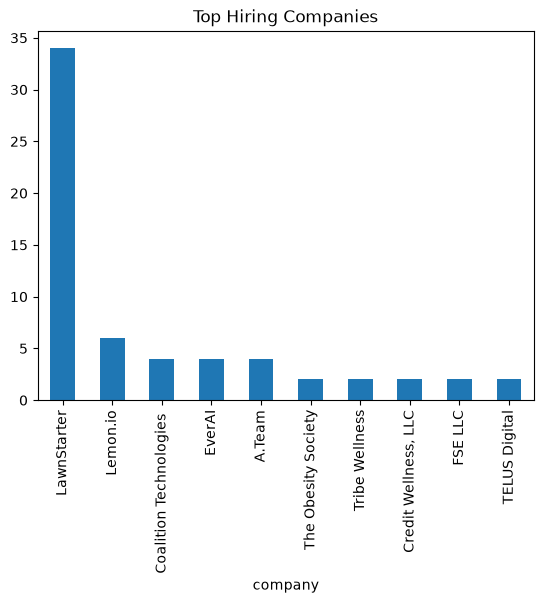

In [54]:
top_companies.head(10).plot(kind="bar")

plt.title("Top Hiring Companies")

plt.show()

In [55]:
jobs["category"].value_counts()

category
Software Development       21
Product Management         14
Quality Assurance          10
Sales                       8
Artificial Intelligence     6
Writing                     4
Customer Service            4
Medical                     2
Marketing                   2
All others                  2
Information Technology      2
Communications              2
Name: count, dtype: int64

In [56]:
jobs["location"].value_counts()

location
Brazil                                             26
Worldwide                                          18
USA                                                 6
Uruguay                                             4
Mexico                                              4
Americas, Europe, Israel                            4
USA, CST (UTC-6)                                    2
Canada                                              2
Northern America, LATAM, Europe, APAC               2
LATAM, Europe                                       2
Northern America, Europe, South Africa              2
Americas, Europe, Asia, Oceania                     2
USA, Canada, USA timezones                          2
Europe, UK, Germany, France, European timezones     1
Name: count, dtype: int64

In [57]:
jobs["job_type"].value_counts()

job_type
full_time    67
freelance     4
contract      4
part_time     2
Name: count, dtype: int64

In [58]:
jobs["salary"].isna().value_counts()

salary
False    77
Name: count, dtype: int64

In [59]:
jobs["salary"].notna().sum()

np.int64(77)

In [60]:
merged = (
    job_skills
    .merge(
        skills,
        left_on="skill_id",
        right_on="id"
    )
)

In [61]:
merged.head()

,id_x,job_id,skill_id,id_y,name
0,1,77,1,1,backend
1,2,77,2,2,frontend
2,3,77,3,3,fullstack
3,4,77,4,4,golang
4,5,77,5,5,postgresql


In [62]:
merged["name"].value_counts()

name
backend                1
frontend               1
fullstack              1
golang                 1
postgresql             1
react                  1
AI/ML                  1
documentation          1
youtube                1
Redis                  1
distributed systems    1
GCP                    1
chat                   1
next.js                1
infrastructure         1
Name: count, dtype: int64

In [63]:
jobs["description_length"] = jobs["description"].str.len()

In [64]:
jobs["description_length"].describe()

count        1.0
mean     24915.0
std          NaN
min      24915.0
25%      24915.0
50%      24915.0
75%      24915.0
max      24915.0
Name: description_length, dtype: float64

In [65]:
words = (
    jobs["title"]
        .str.lower()
        .str.split()
        .explode()
)

In [66]:
words.value_counts().head(25)

title
engineer           31
product            29
staff              24
senior             19
software           14
engineer,          12
quality            10
sales               8
ai                  8
assistant           6
(belo               6
horizonte)          6
(são                6
paulo)              6
(campinas)          6
(florianópolis)     6
specialist          6
(montevideo)        4
(mexico             4
city)               4
&                   4
lead                4
freelance           4
manager             4
mid/senior          4
Name: count, dtype: int64

In [67]:
pd.crosstab(
    jobs["category"],
    jobs["job_type"]
)

job_type,contract,freelance,full_time,part_time
category,,,,
All others,0,0,0,2
Artificial Intelligence,0,0,6,0
Communications,0,0,2,0
Customer Service,0,0,4,0
Information Technology,0,0,2,0
Marketing,0,0,2,0
Medical,0,0,2,0
Product Management,0,0,14,0
Quality Assurance,0,0,10,0
